<a href="https://colab.research.google.com/github/leonidasf300/OUU2026/blob/main/LeonSerna_OUU_project_v0_simple_feeder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple feeder to do a simple model

# Installing libraries

In [1]:
pip install pandapower[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.0/330.0 kB 19.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 19.8 MB/s eta 0:00:00


# Importing libraries

In [3]:
import pandapower as pp
import pandapower.shortcircuit as sc
import pandapower as pp
import pandapower.shortcircuit as sc
import pandas as pd
import warnings
import numpy as np

# Creating IEC MG

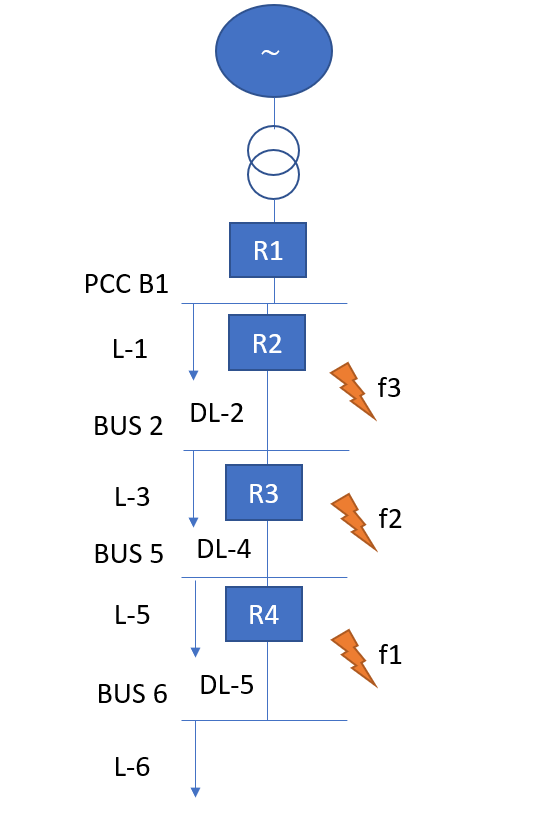

In [22]:


def create_iec_microgrid():
    # Crear red vacía
    net = pp.create_empty_network(f_hz=60.0)

    # ================= BUSES =================
    # Red de utilidad
    bus_utility = pp.create_bus(net, vn_kv=120.0, name="Utility 120kV")

    # Nivel de distribución 25 kV
    bus_pcc = pp.create_bus(net, vn_kv=25.0, name="PCC B1")
    bus2 = pp.create_bus(net, vn_kv=25.0, name="BUS 2")
    #bus3 = pp.create_bus(net, vn_kv=25.0, name="BUS 3")
    #bus4 = pp.create_bus(net, vn_kv=25.0, name="BUS 4")
    bus5 = pp.create_bus(net, vn_kv=25.0, name="BUS 5")
    bus6 = pp.create_bus(net, vn_kv=25.0, name="BUS 6")

    # Buses de Generadores (Baja Tensión)
    #bus_dg1 = pp.create_bus(net, vn_kv=2.4, name="Terminal DG1")
    #bus_dg2 = pp.create_bus(net, vn_kv=2.4, name="Terminal DG2")
    #bus_dg3 = pp.create_bus(net, vn_kv=0.575, name="Terminal DG3")
    #bus_dg4 = pp.create_bus(net, vn_kv=0.575, name="Terminal DG4")

    # ================= GRID EXTERNO =================
    # S_sc = 1000 MVA según Tabla 1
    pp.create_ext_grid(net, bus_utility, s_sc_max_mva=1000.0, rx_max=0.1, name="Utility Grid")

    # ================= TRANSFORMADORES =================
    # R1 = 0.00375 pu -> vkr = 0.375%
    # X1 = 0.1 pu (según artículo) -> vk = sqrt(0.00375^2 + 0.1^2) * 100 = 10.007%
    vkr_val = 0.00375 * 100
    vk_val = np.sqrt(0.00375**2 + 0.1**2) * 100


    # TR-1: 15 MVA, 120/25 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus_utility, lv_bus=bus_pcc, sn_mva=15.0,
                                          vn_hv_kv=120.0, vn_lv_kv=25.0, vkr_percent=vkr_val,
                                          vk_percent=vk_val, pfe_kw=30, i0_percent=0.2828, name="TR-1")
    """
    # TR-2 y TR-3: 12 MVA, 25/2.4 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus2, lv_bus=bus_dg1, sn_mva=12.0,
                                          vn_hv_kv=25.0, vn_lv_kv=2.4, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=24, i0_percent=0.2828, name="TR-2")
    pp.create_transformer_from_parameters(net, hv_bus=bus3, lv_bus=bus_dg2, sn_mva=12.0,
                                          vn_hv_kv=25.0, vn_lv_kv=2.4, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=24, i0_percent=0.2828, name="TR-3")

    # TR-4 y TR-5: 10 MVA, 25/0.575 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus4, lv_bus=bus_dg3, sn_mva=10.0,
                                          vn_hv_kv=25.0, vn_lv_kv=0.575, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=20, i0_percent=0.2828, name="TR-4")
    pp.create_transformer_from_parameters(net, hv_bus=bus6, lv_bus=bus_dg4, sn_mva=10.0,
                                          vn_hv_kv=25.0, vn_lv_kv=0.575, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=20, i0_percent=0.2828, name="TR-5")
    """

    # ================= LÍNEAS DE DISTRIBUCIÓN =================
    # R1 = 0.413 ohm/km, L1 = 3.32e-3 H/km -> X1 = 2*pi*60*3.32e-3 = 1.251 ohm/km
    # C1 = 5.01e-9 F/km
    line_params = {
    "r_ohm_per_km": 0.413,
    "x_ohm_per_km": 1.251,
    "c_nf_per_km": 5.01,
    "r0_ohm_per_km": 0.1153, # Datos de la Tabla 5
    "x0_ohm_per_km": 0.396,  # Calculado de L0
    "c0_nf_per_km": 11.33,   # Datos de la Tabla 5
    "max_i_ka": 1.0
}

    #pp.create_line_from_parameters(net, from_bus=bus_pcc, to_bus=bus3, length_km=30.0, name="DL-1", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus_pcc, to_bus=bus2, length_km=3.0, name="DL-2", **line_params)
    #pp.create_line_from_parameters(net, from_bus=bus2, to_bus=bus4, length_km=3.0, name="DL-3", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus2, to_bus=bus5, length_km=3.0, name="DL-4", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus5, to_bus=bus6, length_km=3.0, name="DL-5", **line_params)

    # Interruptores de lazo (Loop breakers) - Normalmente abiertos para operación radial
    #pp.create_switch(net, bus=bus2, element=bus4, et="b", closed=False, name="CB_LOOP 1")
    #pp.create_switch(net, bus=bus4, element=bus6, et="b", closed=False, name="CB_LOOP 2")

    # ================= GENERADORES DISTRIBUIDOS =================
    # DG1, DG2: Sincrónicos (9 MVA, xd'' = 0.177)
    #pp.create_gen(net, bus_dg1, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=2.4, xdss_pu=0.177, rdss_ohm=0.0, cos_phi=0.9, name="DG1")
    #pp.create_gen(net, bus_dg2, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=2.4, xdss_pu=0.177, rdss_ohm=0.0, cos_phi=0.9, name="DG2")

    # DG3: Inversor Eólico (6 MVA, xd'' = 0.252)
    #pp.create_gen(net, bus_dg3, p_mw=5.4, vm_pu=1.0, sn_mva=6.0, vn_kv=0.575, xdss_pu=0.252, rdss_ohm=0.0, cos_phi=0.9, name="DG3")

    # DG4: DFIG Eólico (9 MVA, Ls + Lr' = 0.34)
    #pp.create_gen(net, bus_dg4, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=0.575, xdss_pu=0.34, rdss_ohm=0.0, cos_phi=0.9, name="DG4")

    # ================= CARGAS =================
    # Total de 22 MW y 10 MVAR dividido en 6 cargas
    p_load = 22.0 / 6.0
    q_load = 10.0 / 6.0

    pp.create_load(net, bus_pcc, p_mw=p_load, q_mvar=q_load, name="L-1")
    pp.create_load(net, bus2, p_mw=p_load, q_mvar=q_load, name="L-2")
    #pp.create_load(net, bus3, p_mw=p_load, q_mvar=q_load, name="L-3")
    #pp.create_load(net, bus4, p_mw=p_load, q_mvar=q_load, name="L-4")
    pp.create_load(net, bus5, p_mw=p_load, q_mvar=q_load, name="L-5")
    pp.create_load(net, bus6, p_mw=p_load, q_mvar=q_load, name="L-6")

    return net

# Inicializar red
net = create_iec_microgrid()

# ================= ANÁLISIS DE CORTOCIRCUITO =================
# Ejecutar cortocircuito trifásico según norma IEC 60909
# case="max" para calcular corrientes máximas de falla
sc.calc_sc(net, case="max", ip=True, ith=True, branch_results=True)

# Imprimir resultados en buses (corriente de cortocircuito subtransitoria ikss)
print("--- Resultados de Cortocircuito en Buses (ikss en kA) ---")
print(net.res_bus_sc[['ikss_ka', 'ip_ka']])

--- Resultados de Cortocircuito en Buses (ikss en kA) ---
    ikss_ka      ip_ka
0  4.811252  11.880038
1  3.309837   8.765273
2  1.831511   4.161496
3  1.261011   2.723410
4  0.960669   2.023350


/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)


In [24]:
#ICC = ICC4.copy()

#columns: main
#rows: back ups
   #R7,R6,R4,R2
#R7
#R6
#R4
#R2
BACKUP = [[0,0,0],#R1
          [1,0,0],#R2
          [1,1,0]]#R3

#R7
#R6
#R4
#R2
CT_PS = [[800,0.5],#[[1200,1],#1
          [400,0.5],#6
          [400,0.5],#4
          [400,0.5]]#2

# faults = {"F1":"DL-5", "F2":"DL-4", "F3":"DL-2", "F4":"DL-1", "F5":"DL-3"}
#             7,6,4,2
#             1,2,3,4
principal = [[0,0,0,1],
              [0,0,1,0],
              [0,1,0,0]]

faults = {"F1":"DL-5", "F2":"DL-4", "F3":"DL-2"}

In [25]:
headers = ["DG0", "DG1", "DG2", "DG3","DG4"]
rows = ["OM1","OM2","OM3","OM4"]

matrix = [[1,0,0,0,0],
          [1,1,1,1,1],
          [1,1,1,0,0],
          [0,1,1,1,1]]

OMS = {
    (rows[i], headers[j]): matrix[i][j]
    for i in range(len(rows))
    for j in range(len(headers))
}



In [26]:

Cindex={"STI":{"A":0.05,"B":0.04,"C":0},
        "SI":{"A":0.14,"B":0.02,"C":0}}
        # "VI":{"A":13.5,"B":1,"C":0},
        # "EI":{"A":80,"B":2,"C":0},
        # "LTI":{"A":120,"B":1,"C":0},
        # "UI":{"A":315.2,"B":2.5,"C":0},
        # "IEEE-LTI":{"A":0.086,"B":0.05,"C":0.185},
        # "IEEE-LTVI":{"A":28.55,"B":2,"C":0.712},
        # "IEEE-LTEI":{"A":64.07,"B":2,"C":0.25},
        # "IEEE-MI":{"A":0.0515,"B":0.02,"C":0.114},
        # "IEEE-VI":{"A":19.61,"B":2,"C":0.491},
        # "IEEE-EI":{"A":28.2,"B":2,"C":0.1217},
        # "IEEE-STI":{"A":0.16758,"B":0.02,"C":0.11858},
        # "IEEE-STEI":{"A":1.281,"B":2,"C":0.005}}
C=["STI", "SI"]#, "VI","EI","LTI","IEEE-LTI","IEEE-LTVI","IEEE-LTEI","IEEE-MI","IEEE-VI","IEEE-EI","IEEE-STI","IEEE-STEI"]


# Function calculate_sc_percentage

In [27]:
net.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,geo,r0_ohm_per_km,x0_ohm_per_km,c0_nf_per_km,g0_us_per_km
0,DL-2,None,1,2,3.0,0.413,1.251,5.01,0.0,1.0,1.0,1,None,True,None,0.1153,0.396,11.33,0.0
1,DL-4,None,2,3,3.0,0.413,1.251,5.01,0.0,1.0,1.0,1,None,True,None,0.1153,0.396,11.33,0.0
2,DL-5,None,3,4,3.0,0.413,1.251,5.01,0.0,1.0,1.0,1,None,True,None,0.1153,0.396,11.33,0.0


In [133]:
def calculate_sc_percentage(net, nombre_linea, pasos=10):
    # 1. Identificar la línea original
    line_idx = net.line[net.line.name == nombre_linea].index[0]
    bus_inicial = net.line.at[line_idx, "from_bus"]
    bus_final = net.line.at[line_idx, "to_bus"]
    L_total = net.line.at[line_idx, "length_km"]
    params = {
        "r_ohm_per_km": net.line.at[line_idx, "r_ohm_per_km"],
        "x_ohm_per_km": net.line.at[line_idx, "x_ohm_per_km"],
        "c_nf_per_km": net.line.at[line_idx, "c_nf_per_km"],
        "max_i_ka": net.line.at[line_idx, "max_i_ka"]
    }

    # 2. Desactivar la línea original
    net.line.at[line_idx, "in_service"] = False

    # Identificar las lineas de los relés y guardarlas directamente
    relay_idx = [
        net.line[net.line.name == "DL-2"].index[0],
        net.line[net.line.name == "DL-4"].index[0],
        net.line[net.line.name == "DL-5"].index[0]
    ]

    pos_virtual_line = relay_idx.index(line_idx)
    resultados = []

    # 3. Iterar cada 10% (o el paso definido)
    for i in range(1, pasos):
        porcentaje = i / pasos
        distancia_falla = L_total * porcentaje

        # Crear bus temporal de falla
        f_bus = pp.create_bus(net, vn_kv=net.bus.at[bus_inicial, "vn_kv"], name=f"Falla_{int(porcentaje*100)}%")

        # Crear los dos tramos de línea que conectan al punto de falla
        l1 = pp.create_line_from_parameters(net, bus_inicial, f_bus, distancia_falla, name="tramo_A", **params)
        l2 = pp.create_line_from_parameters(net, f_bus, bus_final, L_total - distancia_falla, name="tramo_B", **params)
        relay_idx[pos_virtual_line] = l1


        # 4. Ejecutar SC con branch_results=True para ver qué ven los relés en los extremos
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sc.calc_sc(net, bus=f_bus, branch_results=True)

        # Guardar datos: I_total en falla, I que ve Relé inicial (l1), I que ve Relé final (l2)
        # resultados.append({
        #     "Porcentaje": f"{int(porcentaje*100)}%",
        #     "I_falla_total": net.res_bus_sc.ikss_ka.at[f_bus],
        #     "I_Relé_Front": net.res_line_sc.ikss_ka.at[l1],
        #     "I_Relé_Back": net.res_line_sc.ikss_ka.at[l2]
        # })
        #print(net.res_line_sc)
        resultados.append({
            "Porcentaje": porcentaje*100,
            "R0": net.res_line_sc.ikss_ka.at[relay_idx[0]]*1000,
            "R1": net.res_line_sc.ikss_ka.at[relay_idx[1]]*1000,
            "R2": net.res_line_sc.ikss_ka.at[relay_idx[2]]*1000
        })


        # Limpiar para no acumular líneas en el modelo
        pp.drop_lines(net, [l1, l2])
        pp.drop_buses(net, [f_bus])

    # Restaurar línea original
    net.line.at[line_idx, "in_service"] = True
    #return pd.DataFrame(resultados)
    return pd.DataFrame(resultados)

dftest=calculate_sc_percentage(net, nombre_linea="DL-4", pasos=10)
dftest

,Porcentaje,R0,R1,R2
0,10.0,1752.466600,1752.466600,0.0
1,20.0,1679.900233,1679.900233,0.0
2,30.0,1613.053966,1613.053966,0.0
3,40.0,1551.282537,1551.282537,0.0
4,50.0,1494.033467,1494.033467,0.0
5,60.0,1440.831087,1440.831087,0.0
6,70.0,1391.263733,1391.263733,0.0
7,80.0,1344.973400,1344.973400,0.0
8,90.0,1301.647328,1301.647328,0.0


In [134]:
net.bus

,name,vn_kv,type,zone,in_service,geo
0,Utility 120kV,120.0,b,None,True,None
1,PCC B1,25.0,b,None,True,None
2,BUS 2,25.0,b,None,True,None
3,BUS 5,25.0,b,None,True,None
4,BUS 6,25.0,b,None,True,None


In [135]:
sc.calc_sc(net, bus=4, branch_results=True)

/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)


In [136]:
net.res_line_sc.ikss_ka.at[2]

np.float64(0.9606688307458319)

In [137]:
net.res_bus_sc

,ikss_ka,skss_mw,rk_ohm,xk_ohm
4,0.960669,41.598181,3.939448,16.050792


In [138]:
net.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,geo,r0_ohm_per_km,x0_ohm_per_km,c0_nf_per_km,g0_us_per_km
0,DL-2,None,1,2,3.0,0.413,1.251,5.01,0.0,1.0,1.0,1,None,True,None,0.1153,0.396,11.33,0.0
1,DL-4,None,2,3,3.0,0.413,1.251,5.01,0.0,1.0,1.0,1,None,True,None,0.1153,0.396,11.33,0.0
2,DL-5,None,3,4,3.0,0.413,1.251,5.01,0.0,1.0,1.0,1,None,True,None,0.1153,0.396,11.33,0.0


# Beta equation

Base Time Factor Calculation ($\beta_{ficd}$)This equation determines the base time factor ($\beta$) for inverse overcurrent curves (IEC/IEEE), unifying the physical power system currents with the internal relay settings.

$$\beta_{ficd} = \frac{A_c}{\left(\frac{ICC_{ifd}}{Ipickup_i \times CTR_i}\right)^{B_c}-1}$$

* Variable Definitions:$ICC_{ifd}$: Short-circuit current on the primary side $[A]$ (obtained from simulations).
* $Ipickup_i$: Pickup current or tap of relay $i$ on the secondary side $[A]$.
* $CTR_i$: Current Transformer Ratio (CTR) associated with relay $i$ $(\frac{I_{nominal\_primary}}{I_{nominal\_secondary}})$.
* $A_c, B_c$: Mathematical constants defining the shape of the selected inverse curve $c$ (e.g., Very Inverse, Extremely Inverse).

*Consistency Note:* The product $(Ipickup_i \times CTR_i)$ translates the relay setting into primary amperes so it can be directly divided by the fault current.If the term inside the parentheses (PSM) is $\le 1$, it means the fault current is lower than the pickup setting; the relay will not operate, and the mathematical result will be negative (invalid).

In [146]:
Findex=[f"F{i+1}" for i in range(3)]
Rindex=[f"R{i+1}" for i in range(3)]

BETA=dict()
B=dict()

dsteps = 3
steps = [i / dsteps for i in range(1, dsteps)]

for fault in range(len(Findex)):
  ICC_fid = calculate_sc_percentage(net, nombre_linea=faults[Findex[fault]], pasos=dsteps)
  for index, ICCdata in ICC_fid.iterrows():
    for relay in range(len(Rindex)):
      for curve in range(len(C)):
        #print(f"nombre_linea: {faults[Findex[fault]]}, relay: {relay}, fault: {fault}, curve: {curve}")
        #print(ICC_fid)

        ICC = ICCdata[f"R{relay}"]
        dist_fault = ICCdata["Porcentaje"]
        print(f"f:{fault},i:{relay},c:{curve},d:{dist_fault:.2f}")

        PSMif=(ICC)/(CT_PS[relay][0]*CT_PS[relay][1])
        #BETA[Findex[fault],Rindex[relay],C[curve]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)
        BETA[Findex[fault],Rindex[relay],C[curve],steps[index]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)

# for relay in range(len(Rindex)):
#   for fault in range(len(Findex)):
#     for curve in range(len(C)):
#       dsteps = 3
#       steps = [i / dsteps for i in range(1, dsteps)]
#       print(f"nombre_linea: {faults[Findex[fault]]}, relay: {relay}, fault: {fault}, curve: {curve}")
#       ICC_fid = calculate_sc_percentage(net, nombre_linea=faults[Findex[fault]], pasos=dsteps)
#       print(ICC_fid)
#       for index, ICC2 in enumerate(ICC_fid):
#         #PSMif=(ICC[fault][relay])/(CT_PS[relay][0])/CT_PS[relay][1]
#         PSMif=(ICC2)/(CT_PS[relay][0]*CT_PS[relay][1])
#         #BETA[Findex[fault],Rindex[relay],C[curve]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)
#         BETA[Findex[fault],Rindex[relay],C[curve],steps[index]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)

for main in range(len(Rindex)):
  for backup in range(len(Rindex)):
    B[Rindex[main],Rindex[backup]] = BACKUP[main][backup]


f:0,i:0,c:0,d:33.33
f:0,i:0,c:1,d:33.33
f:0,i:1,c:0,d:33.33
f:0,i:1,c:1,d:33.33
f:0,i:2,c:0,d:33.33
f:0,i:2,c:1,d:33.33
f:0,i:0,c:0,d:66.67
f:0,i:0,c:1,d:66.67
f:0,i:1,c:0,d:66.67
f:0,i:1,c:1,d:66.67
f:0,i:2,c:0,d:66.67
f:0,i:2,c:1,d:66.67


f:1,i:0,c:0,d:33.33
f:1,i:0,c:1,d:33.33
f:1,i:1,c:0,d:33.33
f:1,i:1,c:1,d:33.33
f:1,i:2,c:0,d:33.33
f:1,i:2,c:1,d:33.33
f:1,i:0,c:0,d:66.67
f:1,i:0,c:1,d:66.67
f:1,i:1,c:0,d:66.67
f:1,i:1,c:1,d:66.67
f:1,i:2,c:0,d:66.67
f:1,i:2,c:1,d:66.67


f:2,i:0,c:0,d:33.33
f:2,i:0,c:1,d:33.33
f:2,i:1,c:0,d:33.33
f:2,i:1,c:1,d:33.33
f:2,i:2,c:0,d:33.33
f:2,i:2,c:1,d:33.33
f:2,i:0,c:0,d:66.67
f:2,i:0,c:1,d:66.67
f:2,i:1,c:0,d:66.67
f:2,i:1,c:1,d:66.67
f:2,i:2,c:0,d:66.67
f:2,i:2,c:1,d:66.67


In [148]:
# Convert the BETA dictionary to a list of dictionaries for DataFrame creation
beta_data = []
for key, value in BETA.items():
    falla, rele, curva, distancia = key
    beta_data.append({
        'Falla': falla,
        'Rele': rele,
        'Curva': curva,
        'Distancia': distancia,
        'Beta': value
    })

# Create the DataFrame
beta_df = pd.DataFrame(beta_data)

# Display the first few rows of the DataFrame
display(beta_df.head())


,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.333333,1.166623
1,F1,R1,SI,0.333333,6.602352
2,F1,R2,STI,0.333333,0.692737
3,F1,R2,SI,0.333333,3.948105
4,F1,R3,STI,0.333333,0.692737


In [149]:
beta_df[beta_df["Rele"]=="R4"]

,Falla,Rele,Curva,Distancia,Beta


In [150]:
beta_df[beta_df["Beta"]>0]

,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.333333,1.166623
1,F1,R1,SI,0.333333,6.602352
2,F1,R2,STI,0.333333,0.692737
3,F1,R2,SI,0.333333,3.948105
4,F1,R3,STI,0.333333,0.692737
5,F1,R3,SI,0.333333,3.948105
6,F1,R1,STI,0.666667,1.278674
7,F1,R1,SI,0.666667,7.229904
8,F1,R2,STI,0.666667,0.731891
9,F1,R2,SI,0.666667,4.167434


In [155]:
beta_df[beta_df["Falla"]=="F2"]

,Falla,Rele,Curva,Distancia,Beta
12,F2,R1,STI,0.333333,0.880216
13,F2,R1,SI,0.333333,4.998243
14,F2,R2,STI,0.333333,0.577934
15,F2,R2,SI,0.333333,3.304979
16,F2,R3,STI,0.333333,-0.050000
17,F2,R3,SI,0.333333,-0.140000
18,F2,R1,STI,0.666667,0.968820
19,F2,R1,SI,0.666667,5.494511
20,F2,R2,STI,0.666667,0.615961
21,F2,R2,SI,0.666667,3.518017


In [152]:
calculate_sc_percentage(net, nombre_linea="DL-5", pasos=dsteps)

,Porcentaje,R0,R1,R2
0,33.333333,1142.082121,1142.082121,1142.082121
1,66.666667,1043.578206,1043.578206,1043.578206


In [157]:
# Ejemplo paso a paso para depuración
# Tomamos como ejemplo Falla F1 (DL-5), Rele R1, y Curva STI

fault_key = 'F2'
relay_idx = 2 # R1
curve_type = 'STI'

# 1. Obtener nombre de la línea
linea_nombre = faults[fault_key]
print(f"--- Depurando {fault_key} en línea {linea_nombre} para R{relay_idx+1} ---")

# 2. Simular un paso (ej. 33% de la línea)
dsteps = 3
porcentaje_falla = 1 / dsteps

# Ejecutamos la función (sin tocarla) para obtener los valores de corriente
icc_list = calculate_sc_percentage(net, nombre_linea=linea_nombre, pasos=dsteps)
icc_val = icc_list[0] # Tomamos el primer punto
print(f"Corriente calculada (ICC): {icc_val} A")

# 3. Cálculo de PSM (Plug Setting Multiplier)
# CT_PS[relay_idx] es [CT_ratio, Pickup]
ct_ratio = CT_PS[relay_idx][0]
pickup = CT_PS[relay_idx][1]

psm = icc_val / (ct_ratio * pickup)
print(f"Parámetros Rele: CT={ct_ratio}, Pickup={pickup}")
print(f"PSM calculado: {psm}")

# 4. Cálculo de Beta (Ecuación de la curva)
# Beta = A / (PSM^B - 1)
a_val = Cindex[curve_type]['A']
b_val = Cindex[curve_type]['B']

denominador = (psm**b_val) - 1
beta_final = a_val / denominador

print(f"--- Parámetros Curva {curve_type} ---")
print(f"A: {a_val}, B: {b_val}")
print(f"Denominador (PSM^B - 1): {denominador}")
print(f"RESULTADO BETA: {beta_final}")

if denominador < 0:
    print("\nALERTA: El denominador es negativo porque el PSM es menor a 1 (la corriente de falla es menor al pickup).")

--- Depurando F2 en línea DL-4 para R3 ---


KeyError: 0

In [156]:
calcular_sc_porcentual(net, "DL-5", pasos=3)

/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprec

,Porcentaje,I_falla_total,I_Relé_Front,I_Relé_Back
0,33%,1.142082,1.142082,0.0
1,66%,1.043578,1.043578,0.0


In [ ]:


def calcular_sc_porcentual(net, nombre_linea, pasos=10):
    # 1. Identificar la línea original
    line_idx = net.line[net.line.name == nombre_linea].index[0]
    bus_inicial = net.line.at[line_idx, "from_bus"]
    bus_final = net.line.at[line_idx, "to_bus"]
    L_total = net.line.at[line_idx, "length_km"]
    params = {
        "r_ohm_per_km": net.line.at[line_idx, "r_ohm_per_km"],
        "x_ohm_per_km": net.line.at[line_idx, "x_ohm_per_km"],
        "c_nf_per_km": net.line.at[line_idx, "c_nf_per_km"],
        "max_i_ka": net.line.at[line_idx, "max_i_ka"]
    }

    # 2. Desactivar la línea original
    net.line.at[line_idx, "in_service"] = False

    resultados = []

    # 3. Iterar cada 10% (o el paso definido)
    for i in range(1, pasos):
        porcentaje = i / pasos
        distancia_falla = L_total * porcentaje

        # Crear bus temporal de falla
        f_bus = pp.create_bus(net, vn_kv=net.bus.at[bus_inicial, "vn_kv"], name=f"Falla_{int(porcentaje*100)}%")

        # Crear los dos tramos de línea que conectan al punto de falla
        l1 = pp.create_line_from_parameters(net, bus_inicial, f_bus, distancia_falla, name="tramo_A", **params)
        l2 = pp.create_line_from_parameters(net, f_bus, bus_final, L_total - distancia_falla, name="tramo_B", **params)

        # 4. Ejecutar SC con branch_results=True para ver qué ven los relés en los extremos
        sc.calc_sc(net, bus=f_bus, branch_results=True)

        # Guardar datos: I_total en falla, I que ve Relé inicial (l1), I que ve Relé final (l2)
        resultados.append({
            "Porcentaje": f"{int(porcentaje*100)}%",
            "I_falla_total": net.res_bus_sc.ikss_ka.at[f_bus],
            "I_Relé_Front": net.res_line_sc.ikss_ka.at[l1],
            "I_Relé_Back": net.res_line_sc.ikss_ka.at[l2]
        })

        # Limpiar para no acumular líneas en el modelo
        pp.drop_lines(net, [l1, l2])
        pp.drop_buses(net, [f_bus])

    # Restaurar línea original
    net.line.at[line_idx, "in_service"] = True
    return pd.DataFrame(resultados)

# Uso:
df_falla_dl1 = calcular_sc_porcentual(net, "DL-4")
print(df_falla_dl1)

# Plot Beta

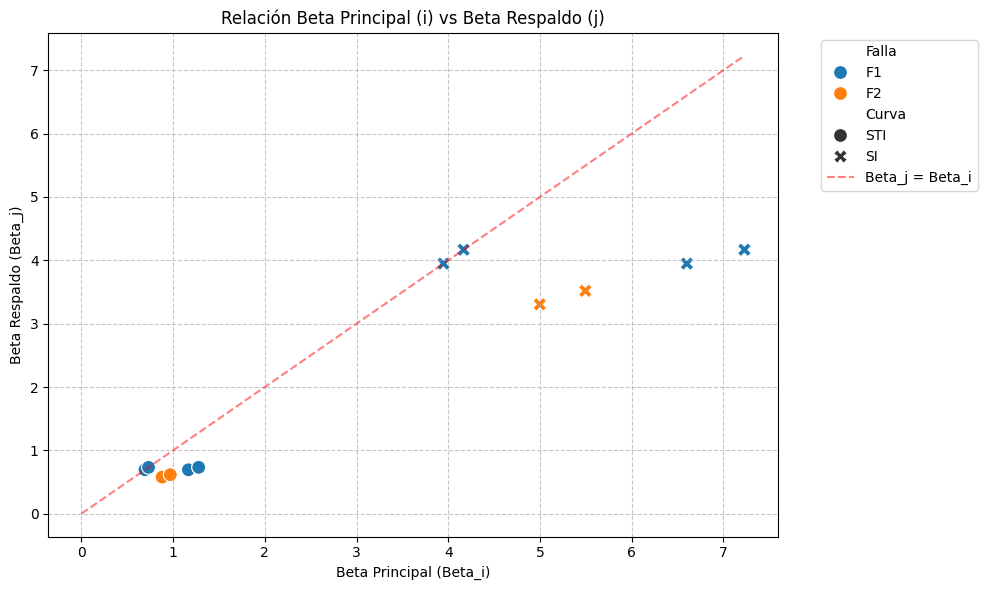

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraer relaciones de la matriz BACKUP
# 'i' es principal (columnas j_idx) y 'j' es respaldo (filas i_idx)
relaciones = []
for i_idx in range(len(BACKUP)):
    for j_idx in range(len(BACKUP[0])):
        if BACKUP[i_idx][j_idx] == 1:
            # i: Principal (columna), j: Respaldo (fila)
            relaciones.append({'i_principal': f'R{j_idx+1}', 'j_respaldo': f'R{i_idx+1}'})

rel_df = pd.DataFrame(relaciones)

# 2. Preparar los datos para la gráfica
# Unimos beta_df para obtener el Beta del relé Principal (i)
data_plot = beta_df.merge(rel_df, left_on='Rele', right_on='i_principal')

# Unimos nuevamente para obtener el Beta del relé de Respaldo (j)
data_plot = data_plot.merge(
    beta_df,
    left_on=['Falla', 'Curva', 'Distancia', 'j_respaldo'],
    right_on=['Falla', 'Curva', 'Distancia', 'Rele'],
    suffixes=('_i', '_j')
)

# Filtramos valores operativos (Beta > 0)
data_plot_clean = data_plot[(data_plot['Beta_i'] > 0) & (data_p
                                                         lot['Beta_j'] > 0)]

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data_plot_clean,
    x='Beta_i',
    y='Beta_j',
    hue='Falla',
    style='Curva',
    s=100
)

# Línea de referencia
if not data_plot_clean.empty:
    all_betas = pd.concat([data_plot_clean['Beta_i'], data_plot_clean['Beta_j']])
    max_val = all_betas.max()
    plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Beta_j = Beta_i')

plt.title('Relación Beta Principal (i) vs Beta Respaldo (j)')
plt.xlabel('Beta Principal (Beta_i)')
plt.ylabel('Beta Respaldo (Beta_j)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#Plot Beta 2


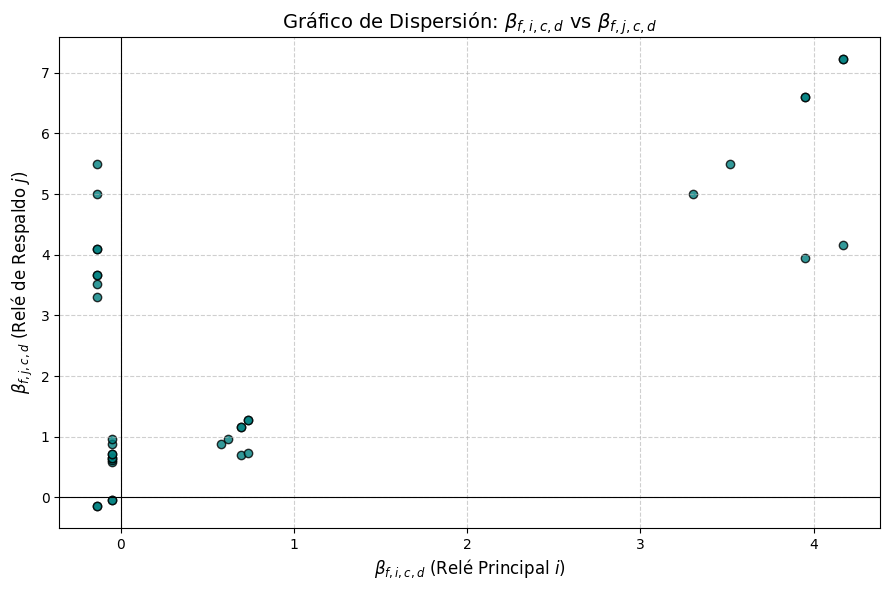

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. Cargar el DataFrame (usando el CSV proporcionado en texto)
csv_data = """Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.3333333333333333,1.1666226399724358
1,F1,R1,SI,0.3333333333333333,6.6023524101647
2,F1,R2,STI,0.3333333333333333,0.6927365540691821
3,F1,R2,SI,0.3333333333333333,3.9481052225277784
4,F1,R3,STI,0.3333333333333333,0.6927365540691821
5,F1,R3,SI,0.3333333333333333,3.9481052225277784
6,F1,R1,STI,0.6666666666666666,1.2786741374513073
7,F1,R1,SI,0.6666666666666666,7.229903928016745
8,F1,R2,STI,0.6666666666666666,0.7318911916669097
9,F1,R2,SI,0.6666666666666666,4.167434313226711
10,F1,R3,STI,0.6666666666666666,0.7318911916669097
11,F1,R3,SI,0.6666666666666666,4.167434313226711
12,F2,R1,STI,0.3333333333333333,0.8802160906310805
13,F2,R1,SI,0.3333333333333333,4.998243303119384
14,F2,R2,STI,0.3333333333333333,0.5779341674379594
15,F2,R2,SI,0.3333333333333333,3.304979476972115
16,F2,R3,STI,0.3333333333333333,-0.05
17,F2,R3,SI,0.3333333333333333,-0.14
18,F2,R1,STI,0.6666666666666666,0.9688198787990735
19,F2,R1,SI,0.6666666666666666,5.494510740711965
20,F2,R2,STI,0.6666666666666666,0.6159612406675303
21,F2,R2,SI,0.6666666666666666,3.5180172909972525
22,F2,R3,STI,0.6666666666666666,-0.05
23,F2,R3,SI,0.6666666666666666,-0.14
24,F3,R1,STI,0.3333333333333333,0.6413380623476326
25,F3,R1,SI,0.3333333333333333,3.6601795394536567
26,F3,R2,STI,0.3333333333333333,-0.05
27,F3,R2,SI,0.3333333333333333,-0.14
28,F3,R3,STI,0.3333333333333333,-0.05
29,F3,R3,SI,0.3333333333333333,-0.14
30,F3,R1,STI,0.6666666666666666,0.7175957856195625
31,F3,R1,SI,0.6666666666666666,4.087357766242501
32,F3,R2,STI,0.6666666666666666,-0.05
33,F3,R2,SI,0.6666666666666666,-0.14
34,F3,R3,STI,0.6666666666666666,-0.05
35,F3,R3,SI,0.6666666666666666,-0.14
"""
beta_df = pd.read_csv(io.StringIO(csv_data), index_col=0)

# 2. Definir la matriz BACKUP y los nombres de los relés
BACKUP = [
    [0, 0, 0], # R1
    [1, 0, 0], # R2
    [1, 1, 0]  # R3
]
reles = ['R1', 'R2', 'R3']

# 3. Encontrar los pares (i, j) válidos iterando sobre la matriz
pares_ij = []
for idx_i, fila in enumerate(BACKUP):
    for idx_j, valor in enumerate(fila):
        if valor == 1:
            pares_ij.append((reles[idx_i], reles[idx_j]))

# 4. Extraer las coordenadas X e Y
puntos_x = [] # Almacenará $\beta_{f,i,c,d}$
puntos_y = [] # Almacenará $\beta_{f,j,c,d}$

# Agrupamos por las condiciones fijas (Falla, Curva, Distancia)
grupos = beta_df.groupby(['Falla', 'Curva', 'Distancia'])

for (f, c, d), grupo in grupos:
    for i, j in pares_ij:
        # Extraemos el valor para el relé principal (i)
        beta_i = grupo[grupo['Rele'] == i]['Beta'].values
        # Extraemos el valor para el relé de respaldo (j)
        beta_j = grupo[grupo['Rele'] == j]['Beta'].values

        # Nos aseguramos de que existan datos para ambos relés en esa condición
        if len(beta_i) > 0 and len(beta_j) > 0:
            puntos_x.append(beta_i[0])
            puntos_y.append(beta_j[0])

# 5. Configurar y mostrar la gráfica
plt.figure(figsize=(9, 6))
plt.scatter(puntos_x, puntos_y, color='teal', alpha=0.8, edgecolor='black')

# Formato matemático para los títulos usando LaTeX renderizado por Matplotlib
plt.title(r'Gráfico de Dispersión: $\beta_{f,i,c,d}$ vs $\beta_{f,j,c,d}$', fontsize=14)
plt.xlabel(r'$\beta_{f,i,c,d}$ (Relé Principal $i$)', fontsize=12)
plt.ylabel(r'$\beta_{f,j,c,d}$ (Relé de Respaldo $j$)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.8) # Línea en Y=0
plt.axvline(0, color='black', linewidth=0.8) # Línea en X=0
plt.tight_layout()
plt.show()

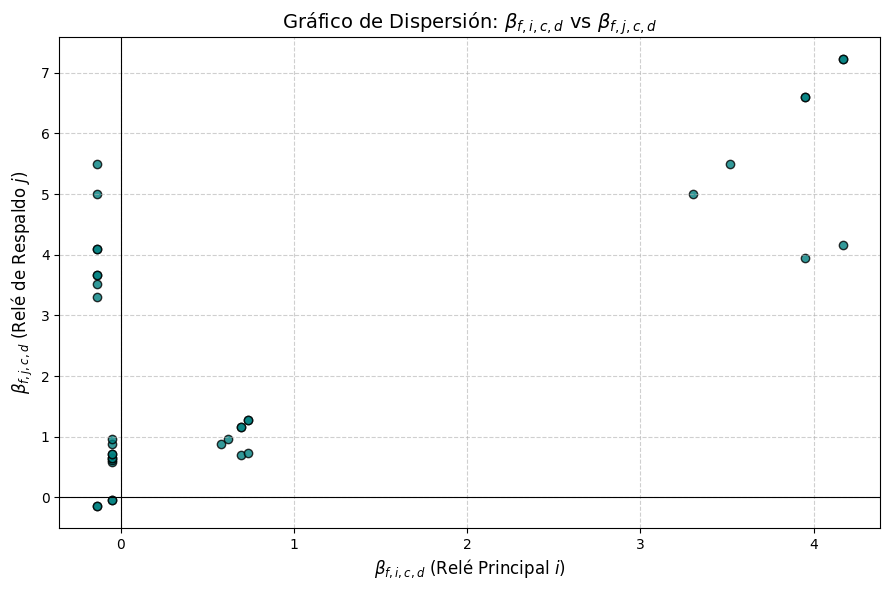

In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. Cargar el DataFrame (usando el CSV proporcionado en texto)
csv_data = """Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.3333333333333333,1.1666226399724358
1,F1,R1,SI,0.3333333333333333,6.6023524101647
2,F1,R2,STI,0.3333333333333333,0.6927365540691821
3,F1,R2,SI,0.3333333333333333,3.9481052225277784
4,F1,R3,STI,0.3333333333333333,0.6927365540691821
5,F1,R3,SI,0.3333333333333333,3.9481052225277784
6,F1,R1,STI,0.6666666666666666,1.2786741374513073
7,F1,R1,SI,0.6666666666666666,7.229903928016745
8,F1,R2,STI,0.6666666666666666,0.7318911916669097
9,F1,R2,SI,0.6666666666666666,4.167434313226711
10,F1,R3,STI,0.6666666666666666,0.7318911916669097
11,F1,R3,SI,0.6666666666666666,4.167434313226711
12,F2,R1,STI,0.3333333333333333,0.8802160906310805
13,F2,R1,SI,0.3333333333333333,4.998243303119384
14,F2,R2,STI,0.3333333333333333,0.5779341674379594
15,F2,R2,SI,0.3333333333333333,3.304979476972115
16,F2,R3,STI,0.3333333333333333,-0.05
17,F2,R3,SI,0.3333333333333333,-0.14
18,F2,R1,STI,0.6666666666666666,0.9688198787990735
19,F2,R1,SI,0.6666666666666666,5.494510740711965
20,F2,R2,STI,0.6666666666666666,0.6159612406675303
21,F2,R2,SI,0.6666666666666666,3.5180172909972525
22,F2,R3,STI,0.6666666666666666,-0.05
23,F2,R3,SI,0.6666666666666666,-0.14
24,F3,R1,STI,0.3333333333333333,0.6413380623476326
25,F3,R1,SI,0.3333333333333333,3.6601795394536567
26,F3,R2,STI,0.3333333333333333,-0.05
27,F3,R2,SI,0.3333333333333333,-0.14
28,F3,R3,STI,0.3333333333333333,-0.05
29,F3,R3,SI,0.3333333333333333,-0.14
30,F3,R1,STI,0.6666666666666666,0.7175957856195625
31,F3,R1,SI,0.6666666666666666,4.087357766242501
32,F3,R2,STI,0.6666666666666666,-0.05
33,F3,R2,SI,0.6666666666666666,-0.14
34,F3,R3,STI,0.6666666666666666,-0.05
35,F3,R3,SI,0.6666666666666666,-0.14
"""
beta_df = pd.read_csv(io.StringIO(csv_data), index_col=0)

# 2. Definir la matriz BACKUP y los nombres de los relés
BACKUP = [
    [0, 0, 0], # R1
    [1, 0, 0], # R2
    [1, 1, 0]  # R3
]
reles = ['R1', 'R2', 'R3']

# 3. Encontrar los pares (i, j) válidos iterando sobre la matriz
pares_ij = []
for idx_i, fila in enumerate(BACKUP):
    for idx_j, valor in enumerate(fila):
        if valor == 1:
            pares_ij.append((reles[idx_i], reles[idx_j]))

# 4. Extraer las coordenadas X e Y
puntos_x = [] # Almacenará $\beta_{f,i,c,d}$
puntos_y = [] # Almacenará $\beta_{f,j,c,d}$

# Agrupamos por las condiciones fijas (Falla, Curva, Distancia)
grupos = beta_df.groupby(['Falla', 'Curva', 'Distancia'])

for (f, c, d), grupo in grupos:
    for i, j in pares_ij:
        # Extraemos el valor para el relé principal (i)
        beta_i = grupo[grupo['Rele'] == i]['Beta'].values
        # Extraemos el valor para el relé de respaldo (j)
        beta_j = grupo[grupo['Rele'] == j]['Beta'].values

        # Nos aseguramos de que existan datos para ambos relés en esa condición
        if len(beta_i) > 0 and len(beta_j) > 0:
            puntos_x.append(beta_i[0])
            puntos_y.append(beta_j[0])

# 5. Configurar y mostrar la gráfica
plt.figure(figsize=(9, 6))
plt.scatter(puntos_x, puntos_y, color='teal', alpha=0.8, edgecolor='black')

# Formato matemático para los títulos usando LaTeX renderizado por Matplotlib
plt.title(r'Gráfico de Dispersión: $\beta_{f,i,c,d}$ vs $\beta_{f,j,c,d}$', fontsize=14)
plt.xlabel(r'$\beta_{f,i,c,d}$ (Relé Principal $i$)', fontsize=12)
plt.ylabel(r'$\beta_{f,j,c,d}$ (Relé de Respaldo $j$)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.8) # Línea en Y=0
plt.axvline(0, color='black', linewidth=0.8) # Línea en X=0
plt.tight_layout()
plt.show()

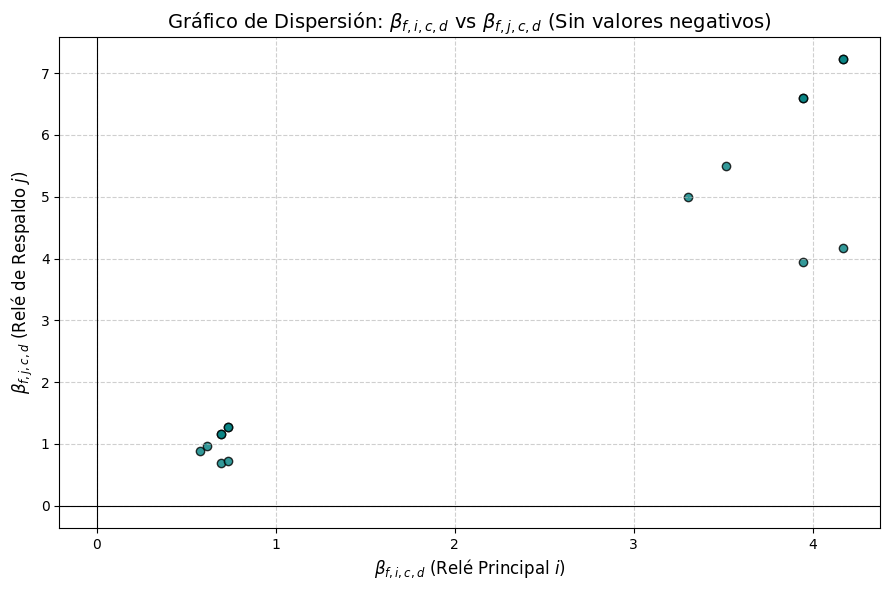

In [166]:

# 1. Filtrar los valores negativos directamente en el DataFrame
# Conservamos solo las filas donde Beta es mayor o igual a 0
df_filtrado = beta_df[beta_df['Beta'] >= 0]

# 2. Definir la matriz BACKUP y los nombres de los relés
BACKUP = [
    [0, 0, 0], # R1
    [1, 0, 0], # R2
    [1, 1, 0]  # R3
]
reles = ['R1', 'R2', 'R3']

# 3. Encontrar los pares (i, j) válidos iterando sobre la matriz
pares_ij = []
for idx_i, fila in enumerate(BACKUP):
    for idx_j, valor in enumerate(fila):
        if valor == 1:
            pares_ij.append((reles[idx_i], reles[idx_j]))

# 4. Extraer las coordenadas X e Y
puntos_x = []
puntos_y = []

# Agrupamos por las condiciones fijas usando el DataFrame ya filtrado
grupos = df_filtrado.groupby(['Falla', 'Curva', 'Distancia'])

for (f, c, d), grupo in grupos:
    for i, j in pares_ij:
        # Extraemos el valor para el relé principal (i)
        beta_i = grupo[grupo['Rele'] == i]['Beta'].values
        # Extraemos el valor para el relé de respaldo (j)
        beta_j = grupo[grupo['Rele'] == j]['Beta'].values

        # Solo agregamos el punto si AMBOS relés tienen datos válidos (positivos)
        if len(beta_i) > 0 and len(beta_j) > 0:
            puntos_x.append(beta_i[0])
            puntos_y.append(beta_j[0])

# 5. Configurar y mostrar la gráfica
plt.figure(figsize=(9, 6))
plt.scatter(puntos_x, puntos_y, color='teal', alpha=0.8, edgecolor='black')

# Formato matemático para los títulos
plt.title(r'Gráfico de Dispersión: $\beta_{f,i,c,d}$ vs $\beta_{f,j,c,d}$ (Sin valores negativos)', fontsize=14)
plt.xlabel(r'$\beta_{f,i,c,d}$ (Relé Principal $i$)', fontsize=12)
plt.ylabel(r'$\beta_{f,j,c,d}$ (Relé de Respaldo $j$)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.8) # Línea en Y=0
plt.axvline(0, color='black', linewidth=0.8) # Línea en X=0
plt.tight_layout()
plt.show()